## **0. Import Libraries**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1. Get the Data**

In [2]:
sales = pd.read_csv('../data/raw/sales_train_validation.csv', index_col='id')
sales.head()

,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
id,,,,,,,,,,,,,,,,,,,,,
HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


In [3]:
sales.shape

(30490, 1918)

In [4]:
sales['cat_id'].value_counts()

cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

In [5]:
sales['state_id'].value_counts()

state_id
CA    12196
TX     9147
WI     9147
Name: count, dtype: int64

In [6]:
cal = pd.read_csv('../data/raw/calendar.csv')
cal.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [7]:
cal.shape

(1969, 14)

In [8]:
prices = pd.read_csv('../data/raw/sell_prices.csv', index_col='store_id')
prices.head()

,item_id,wm_yr_wk,sell_price
store_id,,,
CA_1,HOBBIES_1_001,11325,9.58
CA_1,HOBBIES_1_001,11326,9.58
CA_1,HOBBIES_1_001,11327,8.26
CA_1,HOBBIES_1_001,11328,8.26
CA_1,HOBBIES_1_001,11329,8.26


In [9]:
prices.index.value_counts()

store_id
TX_2    701214
TX_1    699796
CA_1    698412
WI_3    696094
CA_3    693990
TX_3    691112
CA_4    679025
WI_2    678171
WI_1    665912
CA_2    637395
Name: count, dtype: int64

In [10]:
print('The number of stores:', len(prices.index.value_counts()))

The number of stores: 10


In [11]:
prices.shape

(6841121, 3)

## **2. Visualizing total revenue over time**

In [12]:
d_cols = list(sales.drop(columns=['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], axis=0))
daily_sales = sales[d_cols].sum(axis=0)

In [13]:
dates = cal['date'][:len(daily_sales)]

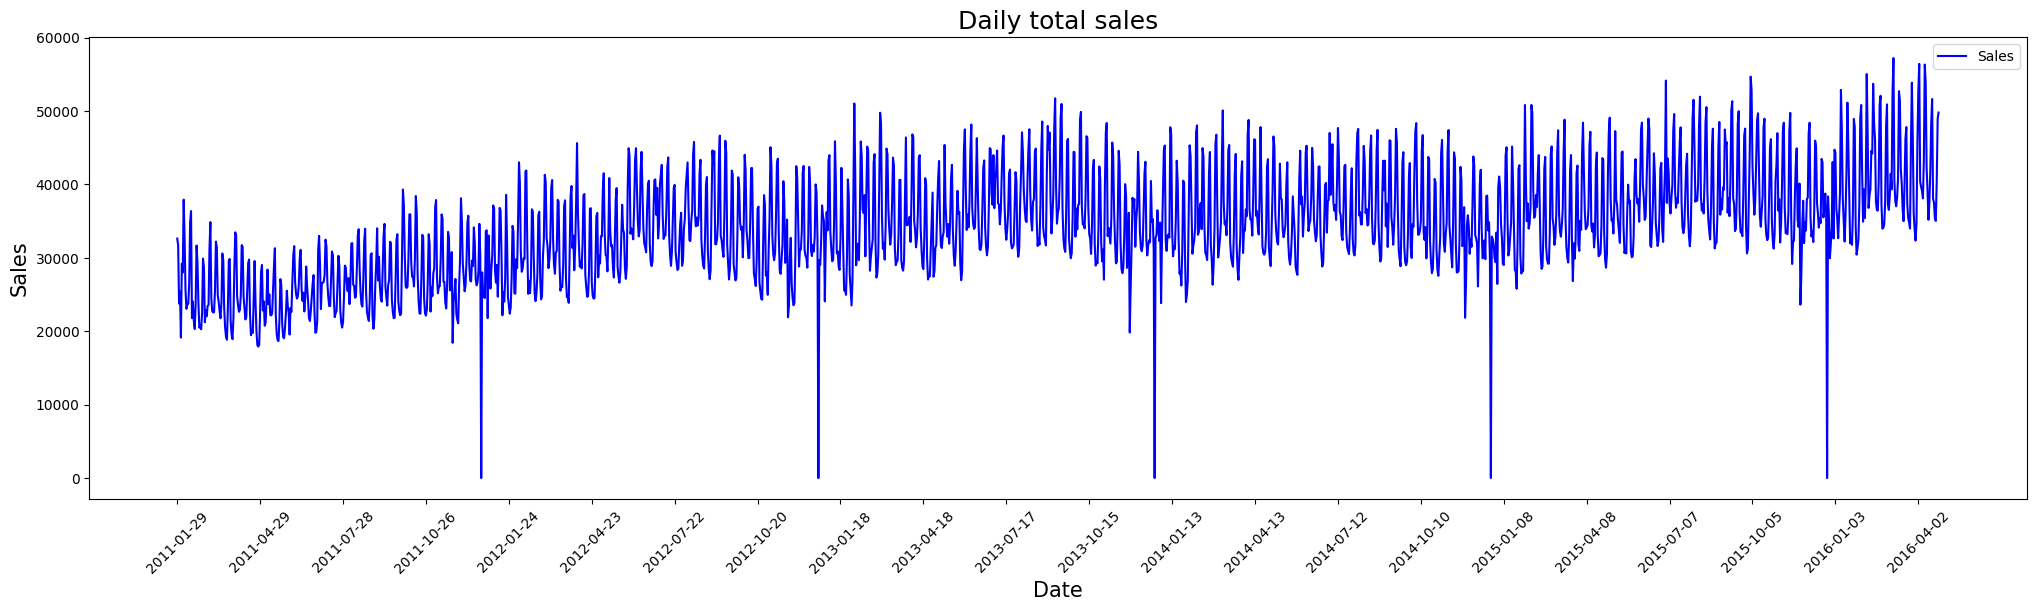

In [155]:
plt.figure(figsize=(25, 6))
plt.plot(dates, daily_sales, label='Sales', color='blue')
plt.title('Daily total sales', fontsize=18)
plt.xlabel('Date', fontsize=15)
plt.ylabel('Sales', fontsize=15)
plt.legend()
plt.xticks(dates[::90], rotation=45)
plt.savefig('../figures/raw/daily_total_sales.png')
plt.show()

In [15]:
daily_sales[daily_sales < 1000]

d_331     13
d_697     11
d_1062    20
d_1427    20
d_1792    14
dtype: int64

In [16]:
date_mapping = cal.set_index('d')['date']
anomaly_days = daily_sales[daily_sales < 1000]
anomaly_dates = anomaly_days.index.map(date_mapping)
anomaly_dates

Index(['2011-12-25', '2012-12-25', '2013-12-25', '2014-12-25', '2015-12-25'], dtype='str')

In [17]:
cal[cal['date'].isin(anomaly_dates.tolist())]

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
330,2011-12-25,11148,Sunday,2,12,2011,d_331,Christmas,National,NaN,NaN,0,0,0
696,2012-12-25,11248,Tuesday,4,12,2012,d_697,Christmas,National,NaN,NaN,0,0,0
1061,2013-12-25,11348,Wednesday,5,12,2013,d_1062,Christmas,National,NaN,NaN,0,0,0
1426,2014-12-25,11447,Thursday,6,12,2014,d_1427,Christmas,National,NaN,NaN,0,0,0
1791,2015-12-25,11547,Friday,7,12,2015,d_1792,Christmas,National,NaN,NaN,0,0,0


In [18]:
sales_df = pd.DataFrame({
    'date': dates,
    'sales': daily_sales.values
})
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df = sales_df.set_index('date')
sales_weekly = sales_df['sales'].rolling(7).mean()
sales_monthly = sales_df['sales'].rolling(30).mean()

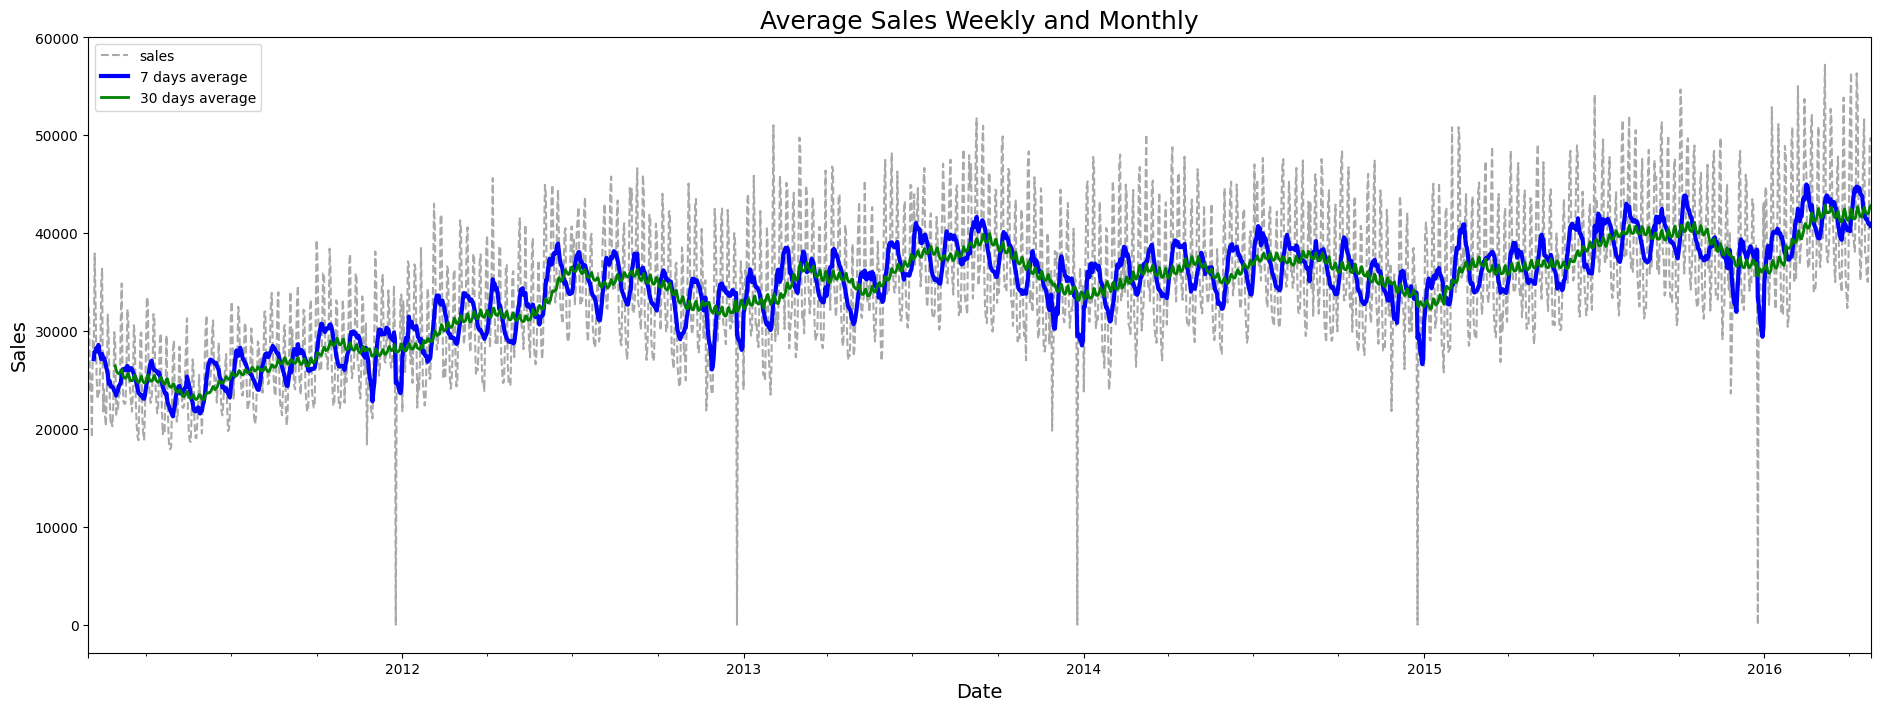

In [156]:
fig, ax = plt.subplots(figsize=(23, 8))
sales_df.plot(ax=ax, legend=True, linestyle='--', color='darkgray')
sales_weekly.plot(ax=ax, legend=True, label='7 days average', linewidth=3, color='blue')
sales_monthly.plot(ax=ax, legend=True, label='30 days average', linewidth=2, color='green')
plt.title('Average Sales Weekly and Monthly', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.savefig('../figures/raw/average_sales_weekly_monthly.png')
plt.show()

In [20]:
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [21]:
weekday_mapping = cal.set_index('d')['weekday']
weekday_sales = pd.DataFrame({
    'weekday': daily_sales.index.map(weekday_mapping),
    'sales': daily_sales.values
})

In [22]:
weekday = weekday_sales.iloc[:, 0]
sales_per_weekday = weekday_sales.iloc[:, 1]

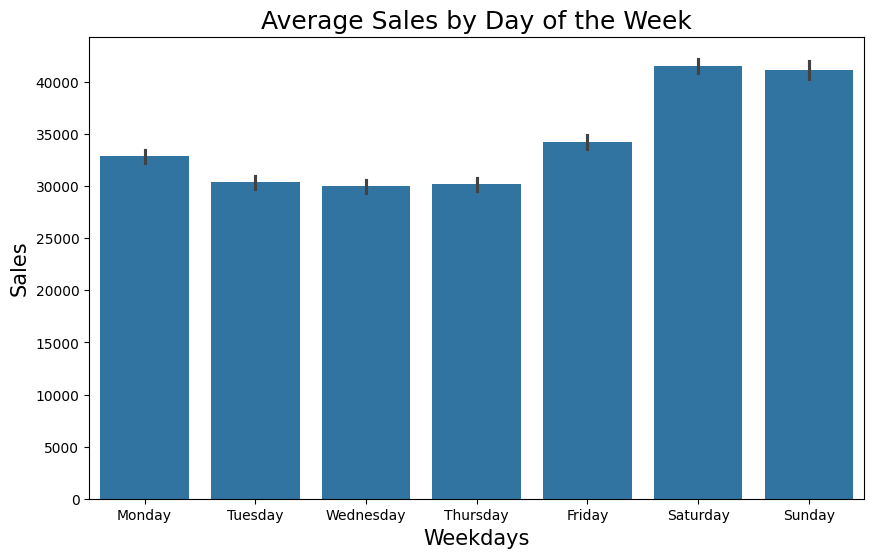

In [157]:
plt.figure(figsize=(10, 6))
sns.barplot(data=weekday_sales, x=weekday, y=sales_per_weekday, order=weekdays, estimator='mean')
plt.title('Average Sales by Day of the Week', fontsize=18)
plt.xlabel('Weekdays', fontsize=15)
plt.ylabel('Sales', fontsize=15)
plt.savefig('../figures/raw/average_sales_weekdays.png')
plt.show()

In [24]:
monthly_mapping = cal.set_index('d')['month']
monthly_sales = pd.DataFrame({
    'month': daily_sales.index.map(monthly_mapping),
    'sales': daily_sales.values
})

In [25]:
months = monthly_sales.iloc[:, 0]
sales_per_month = monthly_sales.iloc[:, 1]

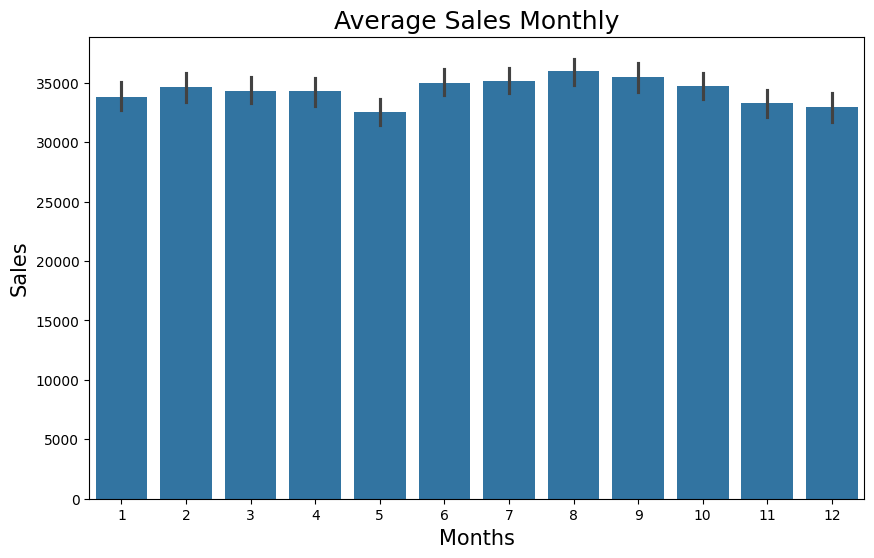

In [158]:
plt.figure(figsize=(10, 6))
sns.barplot(data=monthly_sales, x=months, y=sales_per_month, estimator='mean')
plt.title('Average Sales Monthly', fontsize=18)
plt.xlabel('Months', fontsize=15)
plt.ylabel('Sales', fontsize=15)
plt.savefig('../figures/raw/average_sales_monthly.png')
plt.show()

In [27]:
popular_item_sales_index = sales[d_cols].sum(axis=1).sort_values(ascending=False).index[0]
popular_item_index = sales['item_id'].loc[popular_item_sales_index]
popular_item_store_index = sales['store_id'].loc[popular_item_sales_index]
popular_item_store_index

'CA_3'

In [28]:
popular_item_sales = sales[(sales['item_id'] == popular_item_index) & (sales['store_id'] == popular_item_store_index)]
popular_item_sales = popular_item_sales.drop(columns=['item_id', 'dept_id', 'cat_id', 'state_id', 'store_id']).reset_index()
popular_item_sales = popular_item_sales.set_index('id')
popular_item_sales = popular_item_sales.sum(axis=0)
popular_item_sales

C:\Users\Admin\AppData\Local\Temp\ipykernel_19660\289568386.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  popular_item_sales = popular_item_sales.drop(columns=['item_id', 'dept_id', 'cat_id', 'state_id', 'store_id']).reset_index()


d_1       108
d_2       132
d_3       102
d_4       120
d_5       106
         ... 
d_1909     88
d_1910     77
d_1911    141
d_1912    139
d_1913    130
Length: 1913, dtype: int64

In [29]:
popular_item_cal = (cal['d'].map(popular_item_sales).dropna()).astype(int)

In [30]:
popular_item_cal

0       108
1       132
2       102
3       120
4       106
       ... 
1908     88
1909     77
1910    141
1911    139
1912    130
Name: d, Length: 1913, dtype: int64

In [31]:
popular_item_prices = prices[(prices['item_id'] == popular_item_index) & (prices.index == popular_item_store_index)]
popular_item_prices

,item_id,wm_yr_wk,sell_price
store_id,,,
CA_3,FOODS_3_090,11101,1.25
CA_3,FOODS_3_090,11102,1.25
CA_3,FOODS_3_090,11103,1.25
CA_3,FOODS_3_090,11104,1.25
CA_3,FOODS_3_090,11105,1.25
...,...,...,...
CA_3,FOODS_3_090,11617,1.60
CA_3,FOODS_3_090,11618,1.60
CA_3,FOODS_3_090,11619,1.60


In [32]:
popular_item_df = pd.DataFrame({
    'd': popular_item_sales.index,
    'sales': popular_item_cal.values
})
popular_item_df

,d,sales
0,d_1,108
1,d_2,132
2,d_3,102
3,d_4,120
4,d_5,106
...,...,...
1908,d_1909,88
1909,d_1910,77
1910,d_1911,141
1911,d_1912,139


In [33]:
popular_item_df = popular_item_df.merge(cal[['d', 'date', 'wm_yr_wk']], on='d', how='left')

In [34]:
popular_item_df

,d,sales,date,wm_yr_wk
0,d_1,108,2011-01-29,11101
1,d_2,132,2011-01-30,11101
2,d_3,102,2011-01-31,11101
3,d_4,120,2011-02-01,11101
4,d_5,106,2011-02-02,11101
...,...,...,...,...
1908,d_1909,88,2016-04-20,11612
1909,d_1910,77,2016-04-21,11612
1910,d_1911,141,2016-04-22,11612
1911,d_1912,139,2016-04-23,11613


In [35]:
popular_item_df

,d,sales,date,wm_yr_wk
0,d_1,108,2011-01-29,11101
1,d_2,132,2011-01-30,11101
2,d_3,102,2011-01-31,11101
3,d_4,120,2011-02-01,11101
4,d_5,106,2011-02-02,11101
...,...,...,...,...
1908,d_1909,88,2016-04-20,11612
1909,d_1910,77,2016-04-21,11612
1910,d_1911,141,2016-04-22,11612
1911,d_1912,139,2016-04-23,11613


In [36]:
popular_item_prices.shape

(282, 3)

In [37]:
popular_item_df = popular_item_df.merge(popular_item_prices[['wm_yr_wk', 'sell_price']], on='wm_yr_wk', how='left').drop_duplicates()

In [41]:
popular_item_df

,d,sales,date,wm_yr_wk,sell_price
index,,,,,
0,d_1,108,2011-01-29,11101,1.25
1,d_2,132,2011-01-30,11101,1.25
2,d_3,102,2011-01-31,11101,1.25
3,d_4,120,2011-02-01,11101,1.25
4,d_5,106,2011-02-02,11101,1.25
...,...,...,...,...,...
1908,d_1909,88,2016-04-20,11612,1.60
1909,d_1910,77,2016-04-21,11612,1.60
1910,d_1911,141,2016-04-22,11612,1.60


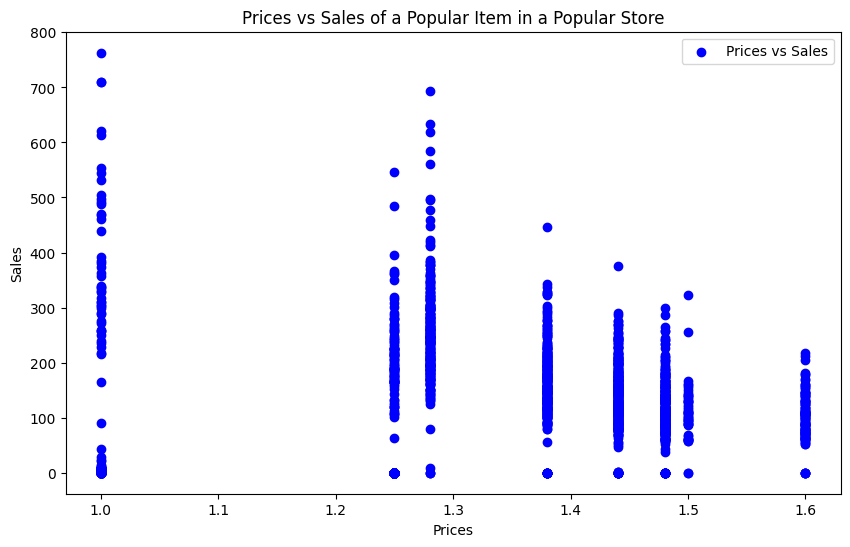

In [159]:
plt.figure(figsize=(10, 6))
plt.scatter(popular_item_df['sell_price'], popular_item_df['sales'], color='blue', label='Prices vs Sales')
plt.title('Prices vs Sales of a Popular Item in a Popular Store')
plt.legend()
plt.xlabel('Prices')
plt.ylabel('Sales')
plt.savefig('../figures/raw/prices_sales_popular_item_store.png')
plt.show()

In [49]:
sales.columns

Index(['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2',
       'd_3', 'd_4', 'd_5',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='str', length=1918)

In [145]:
cat_sales = sales.drop(columns=['item_id', 'dept_id', 'store_id', 'state_id'])
cat_sales = cat_sales.groupby('cat_id').sum()

In [146]:
cat_sales

,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
cat_id,,,,,,,,,,,,,,,,,,,,,
FOODS,23178,22758,17174,18878,14603,22093,20490,27751,24862,18901,...,28682,32007,34497,26151,24948,23632,23317,26704,31927,32654
HOBBIES,3764,3357,2682,2669,1814,3220,2944,3986,2899,2615,...,3786,4634,4820,3323,3787,3472,3353,4085,4787,4683
HOUSEHOLD,5689,5634,3927,3865,2729,3898,4576,6195,4975,4056,...,9321,11721,12323,8585,8835,8239,8363,9728,12248,12458


In [152]:
cat_sales.index = dates

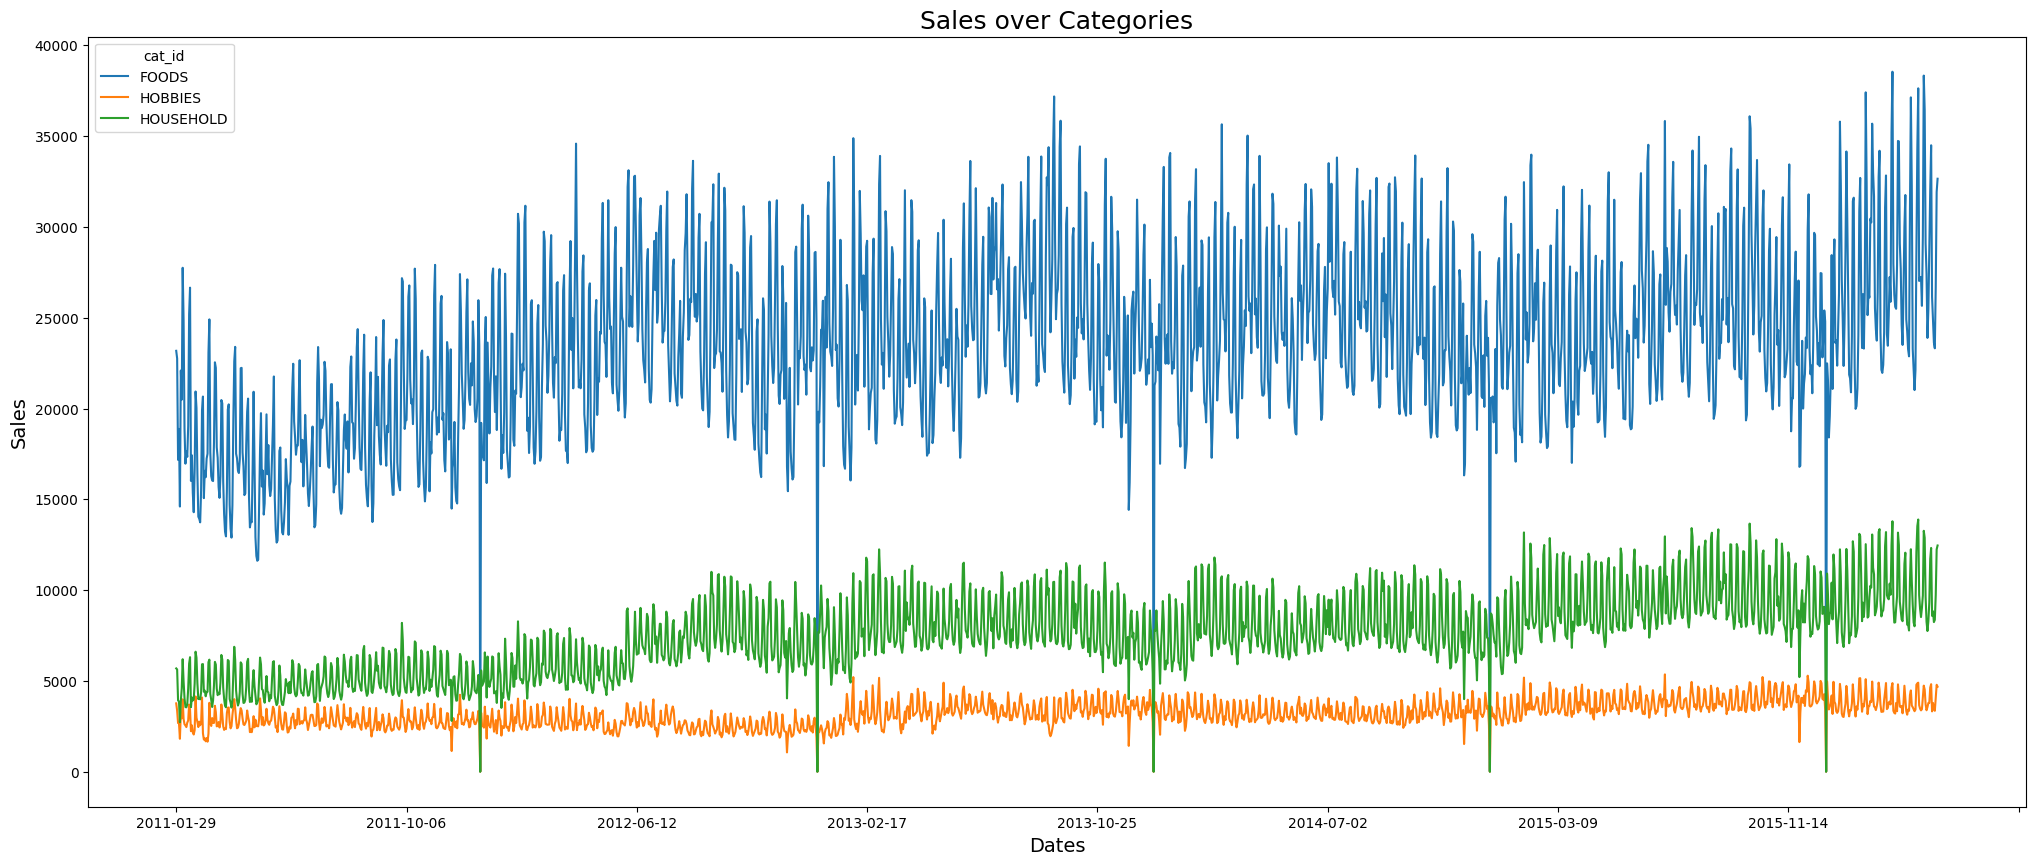

In [160]:
cat_sales.plot(figsize=(25, 10))
plt.title('Sales over Categories', fontsize=18)
plt.xlabel('Dates', fontsize=14)
plt.ylabel('Sales', fontsize=14)
plt.savefig('../figures/raw/sales_over_categories.png')
plt.show()